# 🔷  **Normalization**

**✅ Normalization: Global vs Channel-wise (EEG best practice)**

Device: cuda
Normalization mode: channel
Epoch 1/100 - Loss:100.7154 Train Acc:83.57% Val Acc:80.09% Train F1:0.8357 Val F1:0.7944
Epoch 2/100 - Loss:80.8467 Train Acc:89.43% Val Acc:85.12% Train F1:0.8943 Val F1:0.8495
Epoch 3/100 - Loss:69.7218 Train Acc:91.35% Val Acc:62.47% Train F1:0.9135 Val F1:0.5640
Epoch 4/100 - Loss:63.8986 Train Acc:92.55% Val Acc:90.59% Train F1:0.9255 Val F1:0.9058
Epoch 5/100 - Loss:61.7574 Train Acc:92.69% Val Acc:93.00% Train F1:0.9269 Val F1:0.9299
Epoch 6/100 - Loss:55.7143 Train Acc:93.76% Val Acc:93.33% Train F1:0.9375 Val F1:0.9332
Epoch 7/100 - Loss:52.9796 Train Acc:93.67% Val Acc:80.31% Train F1:0.9367 Val F1:0.7965
Epoch 8/100 - Loss:51.7171 Train Acc:94.03% Val Acc:93.44% Train F1:0.9403 Val F1:0.9342
Epoch 9/100 - Loss:47.8160 Train Acc:94.91% Val Acc:93.33% Train F1:0.9491 Val F1:0.9332
Epoch 10/100 - Loss:45.7245 Train Acc:94.69% Val Acc:95.08% Train F1:0.9469 Val F1:0.9508
Epoch 11/100 - Loss:45.4925 Train Acc:95.29% Val Acc:91.14% Train F

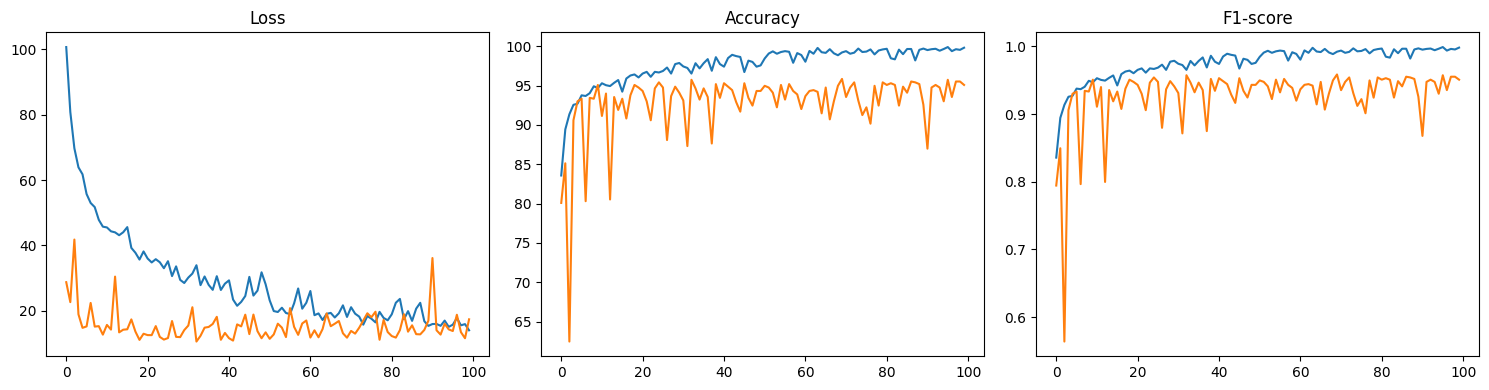

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Normalization: Global vs Channel-wise (EEG best practice)
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

# ============================================================
# NORMALIZATION OPTIONS
# ============================================================

NORMALIZATION_MODE = "channel"
# options: "global" | "channel"

# ---- GLOBAL NORMALIZATION ----
if NORMALIZATION_MODE == "global":
    X = (X - X.mean()) / (X.std() + 1e-6)

# ---- CHANNEL-WISE NORMALIZATION (RECOMMENDED EEG) ----
elif NORMALIZATION_MODE == "channel":
    # assumes shape: (N, C, T)
    X = (X - X.mean(axis=(0, 2), keepdims=True)) / (X.std(axis=(0, 2), keepdims=True) + 1e-6)

print("Normalization mode:", NORMALIZATION_MODE)

# ============================================================
# TRAIN / VAL SPLIT
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL 1D (optimized)
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[-1, 0, 1]], dtype=torch.float32).view(1, 1, 3)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        w = self.weight.repeat(C, 1, 1)
        return F.conv1d(x, w, padding=1, groups=C).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN-like MIXER (MLP-based)
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS / OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# TRAINING HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAIN LOOP
# ============================================================

num_epochs = 100
start_time = datetime.now()

for epoch in range(num_epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        loss += 0.3 * criterion(ds[0], yb)
        loss += 0.3 * criterion(ds[1], yb)
        loss += 0.3 * criterion(ds[2], yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ---------------- VALIDATION ----------------
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, ds = model(x)

            loss = criterion(logits, yb)
            loss += 0.3 * criterion(ds[0], yb)
            loss += 0.3 * criterion(ds[1], yb)
            loss += 0.3 * criterion(ds[2], yb)

            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ---------------- METRICS ----------------
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(history["train_loss"])
ax[0].plot(history["val_loss"])
ax[0].set_title("Loss")

ax[1].plot(history["train_acc"])
ax[1].plot(history["val_acc"])
ax[1].set_title("Accuracy")

ax[2].plot(history["train_f1"])
ax[2].plot(history["val_f1"])
ax[2].set_title("F1-score")

plt.tight_layout()
plt.show()

**✅ NORMALIZATION OPTIONS (Global / Channel / Subject-wise)**

Device: cuda
Normalization mode: channel
Epoch 1/100 - Loss:96.6919 Train Acc:85.38% Val Acc:78.12% Train F1:0.8538 Val F1:0.7721
Epoch 2/100 - Loss:77.2281 Train Acc:89.98% Val Acc:89.72% Train F1:0.8998 Val F1:0.8967
Epoch 3/100 - Loss:71.3127 Train Acc:90.17% Val Acc:88.18% Train F1:0.9017 Val F1:0.8806
Epoch 4/100 - Loss:63.7688 Train Acc:91.92% Val Acc:90.48% Train F1:0.9192 Val F1:0.9046
Epoch 5/100 - Loss:59.3230 Train Acc:92.47% Val Acc:89.82% Train F1:0.9247 Val F1:0.8975
Epoch 6/100 - Loss:54.5460 Train Acc:93.70% Val Acc:70.02% Train F1:0.9370 Val F1:0.6725
Epoch 7/100 - Loss:60.7799 Train Acc:91.87% Val Acc:95.95% Train F1:0.9186 Val F1:0.9595
Epoch 8/100 - Loss:50.8300 Train Acc:94.36% Val Acc:93.00% Train F1:0.9436 Val F1:0.9298
Epoch 9/100 - Loss:49.4587 Train Acc:94.55% Val Acc:91.36% Train F1:0.9455 Val F1:0.9133
Epoch 10/100 - Loss:45.9101 Train Acc:95.04% Val Acc:94.86% Train F1:0.9504 Val F1:0.9485
Epoch 11/100 - Loss:48.6046 Train Acc:94.55% Val Acc:94.86% Train F1

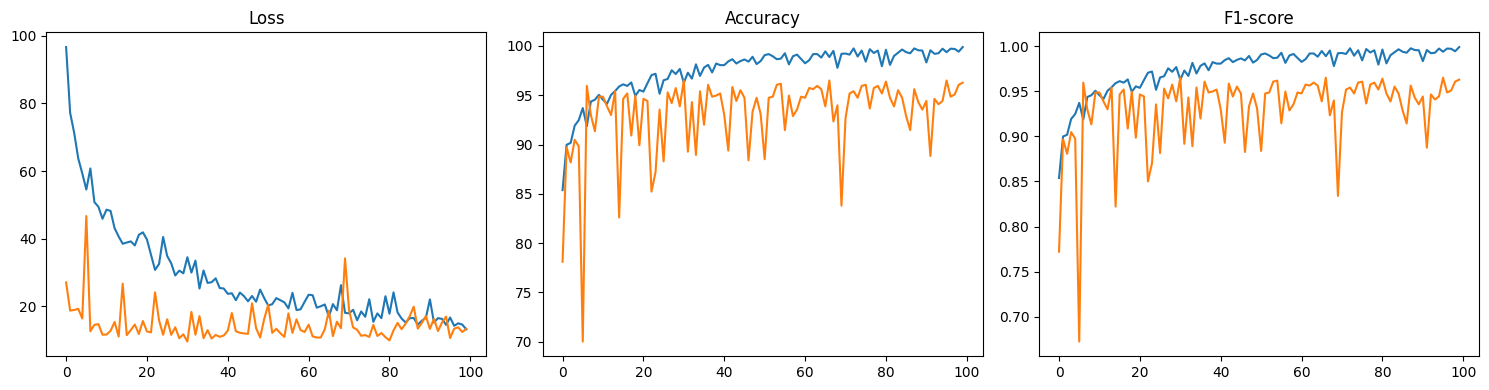

In [ ]:
# ============================================================
# EEG FEW-SHOT / DEEP LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# WITH NORMALIZATION OPTIONS (Global / Channel / Subject-wise)
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

# OPTIONAL: subject labels (if available)
# subject_id = mat["subject_id"].squeeze()

# ============================================================
# NORMALIZATION CONFIG
# ============================================================

NORMALIZATION_MODE = "channel"
# options: "global", "channel", "subject"

# ---------------- GLOBAL ----------------
if NORMALIZATION_MODE == "global":
    X = (X - X.mean()) / (X.std() + 1e-6)

# ---------------- CHANNEL-WISE (BEST EEG DEFAULT) ----------------
elif NORMALIZATION_MODE == "channel":
    X = (X - X.mean(axis=(0, 2), keepdims=True)) / (X.std(axis=(0, 2), keepdims=True) + 1e-6)

# ---------------- SUBJECT-WISE (MULTI-SUBJECT ONLY) ----------------
elif NORMALIZATION_MODE == "subject":
    # NOTE: requires subject_id array
    X_norm = np.zeros_like(X)

    for s in np.unique(subject_id):
        idx = subject_id == s
        scaler = StandardScaler()

        X_s = X[idx].reshape(len(X[idx]), -1)
        X_norm[idx] = scaler.fit_transform(X_s).reshape(X[idx].shape)

    X = X_norm

print("Normalization mode:", NORMALIZATION_MODE)

# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL 1D
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[-1, 0, 1]], dtype=torch.float32).view(1, 1, 3)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        w = self.weight.repeat(C, 1, 1)
        return F.conv1d(x, w, padding=1, groups=C).abs()

# ============================================================
# ATTENTION MODULE
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN-STYLE MIXER (MLP)
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        # Deep supervision heads
        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# TRAINING HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAIN LOOP
# ============================================================

num_epochs = 100
start_time = datetime.now()

for epoch in range(num_epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        loss += 0.3 * criterion(ds[0], yb)
        loss += 0.3 * criterion(ds[1], yb)
        loss += 0.3 * criterion(ds[2], yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ---------------- VALIDATION ----------------
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, ds = model(x)

            loss = criterion(logits, yb)
            loss += 0.3 * criterion(ds[0], yb)
            loss += 0.3 * criterion(ds[1], yb)
            loss += 0.3 * criterion(ds[2], yb)

            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ---------------- METRICS ----------------
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(history["train_loss"])
ax[0].plot(history["val_loss"])
ax[0].set_title("Loss")

ax[1].plot(history["train_acc"])
ax[1].plot(history["val_acc"])
ax[1].set_title("Accuracy")

ax[2].plot(history["train_f1"])
ax[2].plot(history["val_f1"])
ax[2].set_title("F1-score")

plt.tight_layout()
plt.show()